# Prediction and Analysis of Stock Markets Using ARIMA Models

This project analyzes historical stock market data of Amazon, Apple, and Microsoft using LSTM and ARIMA models to predict stock price movements and compare the performance of both forecasting methods.

## Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.optimizers import Adam

print("All libraries imported successfully.")

All libraries imported successfully.


## Data Collection

In [3]:
tickers = {
    "Amazon": "AMZN",
    "Apple": "AAPL",
    "Microsoft": "MSFT"
}

start_date = "2018-01-01"
end_date = "2023-12-01"

stock_data = {}

for company, ticker in tickers.items():
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False
    )

    stock_data[company] = data

    print(f"{company}: {data.shape}")

Amazon: (1489, 6)
Apple: (1489, 6)
Microsoft: (1489, 6)


## Data Preprocessing

In [4]:
amazon = stock_data["Amazon"].copy()
apple = stock_data["Apple"].copy()
microsoft = stock_data["Microsoft"].copy()

# Keep the closing stock price
amazon = amazon[["Close"]].dropna()
apple = apple[["Close"]].dropna()
microsoft = microsoft[["Close"]].dropna()

print("Amazon:", amazon.shape, "- Missing values:", amazon.isnull().sum().sum())
print("Apple:", apple.shape, "- Missing values:", apple.isnull().sum().sum())
print("Microsoft:", microsoft.shape, "- Missing values:", microsoft.isnull().sum().sum())

Amazon: (1489, 1) - Missing values: 0
Apple: (1489, 1) - Missing values: 0
Microsoft: (1489, 1) - Missing values: 0


## Data Scaling

In [5]:
# Create separate scalers for each company
amazon_scaler = MinMaxScaler(feature_range=(0, 1))
apple_scaler = MinMaxScaler(feature_range=(0, 1))
microsoft_scaler = MinMaxScaler(feature_range=(0, 1))

# 80% point used only to fit the scalers
amazon_train_size = int(len(amazon) * 0.80)
apple_train_size = int(len(apple) * 0.80)
microsoft_train_size = int(len(microsoft) * 0.80)

# Fit on training data and transform the complete series
amazon_scaler.fit(amazon.iloc[:amazon_train_size])
apple_scaler.fit(apple.iloc[:apple_train_size])
microsoft_scaler.fit(microsoft.iloc[:microsoft_train_size])

amazon_scaled = amazon_scaler.transform(amazon)
apple_scaled = apple_scaler.transform(apple)
microsoft_scaled = microsoft_scaler.transform(microsoft)

print("Amazon scaled:", amazon_scaled.shape)
print("Apple scaled:", apple_scaled.shape)
print("Microsoft scaled:", microsoft_scaled.shape)

print("\nAmazon scaled range:",
      round(amazon_scaled.min(), 4),
      "to",
      round(amazon_scaled.max(), 4))


Amazon scaled: (1489, 1)
Apple scaled: (1489, 1)
Microsoft scaled: (1489, 1)

Amazon scaled range: 0.0 to 1.0


## Sequence Creation

In [6]:
def create_sequences(data, time_steps=3):
    X = []
    y = []

    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])
        y.append(data[i])

    return np.array(X), np.array(y)


time_steps = 3

X_amazon, y_amazon = create_sequences(amazon_scaled, time_steps)
X_apple, y_apple = create_sequences(apple_scaled, time_steps)
X_microsoft, y_microsoft = create_sequences(microsoft_scaled, time_steps)

print("Amazon:", X_amazon.shape, y_amazon.shape)
print("Apple:", X_apple.shape, y_apple.shape)
print("Microsoft:", X_microsoft.shape, y_microsoft.shape)

Amazon: (1486, 3, 1) (1486, 1)
Apple: (1486, 3, 1) (1486, 1)
Microsoft: (1486, 3, 1) (1486, 1)


## Train, Validation and Test Split

In [7]:
def split_data(X, y):
    train_end = int(len(X) * 0.80)
    val_end = int(len(X) * 0.90)

    X_train = X[:train_end]
    y_train = y[:train_end]

    X_val = X[train_end:val_end]
    y_val = y[train_end:val_end]

    X_test = X[val_end:]
    y_test = y[val_end:]

    return X_train, y_train, X_val, y_val, X_test, y_test


# Amazon
X_train_amazon, y_train_amazon, X_val_amazon, y_val_amazon, X_test_amazon, y_test_amazon = split_data(
    X_amazon, y_amazon
)

# Apple
X_train_apple, y_train_apple, X_val_apple, y_val_apple, X_test_apple, y_test_apple = split_data(
    X_apple, y_apple
)

# Microsoft
X_train_microsoft, y_train_microsoft, X_val_microsoft, y_val_microsoft, X_test_microsoft, y_test_microsoft = split_data(
    X_microsoft, y_microsoft
)

print("Amazon")
print("Train:", X_train_amazon.shape, y_train_amazon.shape)
print("Validation:", X_val_amazon.shape, y_val_amazon.shape)
print("Test:", X_test_amazon.shape, y_test_amazon.shape)

print("\nApple")
print("Train:", X_train_apple.shape, y_train_apple.shape)
print("Validation:", X_val_apple.shape, y_val_apple.shape)
print("Test:", X_test_apple.shape, y_test_apple.shape)

print("\nMicrosoft")
print("Train:", X_train_microsoft.shape, y_train_microsoft.shape)
print("Validation:", X_val_microsoft.shape, y_val_microsoft.shape)
print("Test:", X_test_microsoft.shape, y_test_microsoft.shape)

Amazon
Train: (1188, 3, 1) (1188, 1)
Validation: (149, 3, 1) (149, 1)
Test: (149, 3, 1) (149, 1)

Apple
Train: (1188, 3, 1) (1188, 1)
Validation: (149, 3, 1) (149, 1)
Test: (149, 3, 1) (149, 1)

Microsoft
Train: (1188, 3, 1) (1188, 1)
Validation: (149, 3, 1) (149, 1)
Test: (149, 3, 1) (149, 1)


## Amazon LSTM Model

In [8]:
amazon_lstm = Sequential([
    Input(shape=(3, 1)),
    LSTM(64),
    Dense(32, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1)
])

amazon_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

amazon_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,065 (78.38 KB)

 Trainable params: 20,065 (78.38 KB)

 Non-trainable params: 0 (0.00 B)

### Train Amazon LSTM Model

In [9]:
amazon_history = amazon_lstm.fit(
    X_train_amazon,
    y_train_amazon,
    validation_data=(X_val_amazon, y_val_amazon),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1173 - val_loss: 0.0289
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0095 - val_loss: 0.0018
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - val_loss: 7.6788e-04
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.1622e-04 - val_loss: 8.1548e-04
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.0307e-04 - val_loss: 8.1490e-04
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.7843e-04 - val_loss: 7.8914e-04
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.8023e-04 - val_loss: 8.2549e-04
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.8386e-04 - val_loss: 8.5671e-04
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.9924e-04 - val_loss: 7.9838e-04
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.7195e-04 - val_loss: 8.9533e-04
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.4616e-04 - val_loss: 9.085

## Amazon LSTM Model Evaluation

In [10]:
# Predict Amazon test data
amazon_pred_scaled = amazon_lstm.predict(
    X_test_amazon,
    verbose=0
)

# Convert predictions and actual values back to stock-price scale
amazon_pred = amazon_scaler.inverse_transform(amazon_pred_scaled)
amazon_actual = amazon_scaler.inverse_transform(y_test_amazon)

# Calculate Mean Absolute Error
amazon_lstm_mae = mean_absolute_error(
    amazon_actual.flatten(),
    amazon_pred.flatten()
)

print(f"Amazon LSTM MAE: {amazon_lstm_mae:.4f}")

Amazon LSTM MAE: 2.1884


## Amazon LSTM Accuracy

In [11]:
amazon_lstm_mape = np.mean(
    np.abs(
        (amazon_actual.flatten() - amazon_pred.flatten())
        / amazon_actual.flatten()
    )
) * 100

amazon_lstm_accuracy = 100 - amazon_lstm_mape

print(f"Amazon LSTM Accuracy: {amazon_lstm_accuracy:.2f}%")

Amazon LSTM Accuracy: 98.31%


## Amazon LSTM Prediction Results

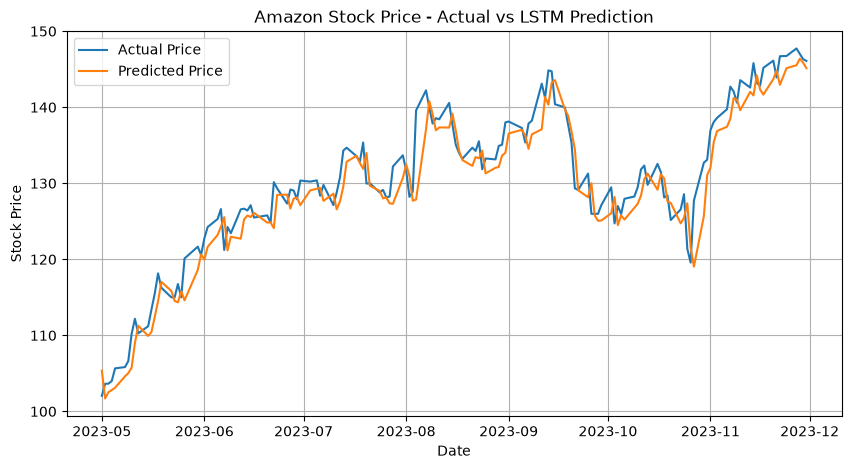

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    amazon.index[-len(amazon_actual):],
    amazon_actual.flatten(),
    label="Actual Price"
)

plt.plot(
    amazon.index[-len(amazon_pred):],
    amazon_pred.flatten(),
    label="Predicted Price"
)

plt.title("Amazon Stock Price - Actual vs LSTM Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.show()

## Amazon ARIMA Model

In [13]:
# Prepare Amazon data for ARIMA
amazon_prices = amazon["Close"].values.flatten()

test_size = len(y_test_amazon)

amazon_arima_train = amazon_prices[:-test_size]
amazon_arima_test = amazon_prices[-test_size:]

print("ARIMA Training Data:", amazon_arima_train.shape)
print("ARIMA Test Data:", amazon_arima_test.shape)

ARIMA Training Data: (1340,)
ARIMA Test Data: (149,)


### Train Amazon ARIMA Model

In [14]:
amazon_arima_model = ARIMA(
    amazon_arima_train,
    order=(5, 1, 0)
)

amazon_arima_fit = amazon_arima_model.fit()

amazon_arima_pred = amazon_arima_fit.forecast(
    steps=len(amazon_arima_test)
)

print("Amazon ARIMA model trained successfully.")
print("Predictions:", len(amazon_arima_pred))

Amazon ARIMA model trained successfully.
Predictions: 149


## Amazon ARIMA Model Evaluation

In [15]:
history = list(amazon_arima_train)
amazon_arima_rolling_pred = []

for actual_value in amazon_arima_test:
    model = ARIMA(history, order=(5, 1, 0))
    model_fit = model.fit()

    prediction = model_fit.forecast(steps=1)[0]
    amazon_arima_rolling_pred.append(prediction)

    history.append(actual_value)

amazon_arima_rolling_pred = np.array(amazon_arima_rolling_pred)

amazon_arima_mae = mean_absolute_error(
    amazon_arima_test,
    amazon_arima_rolling_pred
)

amazon_arima_mape = np.mean(
    np.abs(
        (amazon_arima_test - amazon_arima_rolling_pred)
        / amazon_arima_test
    )
) * 100

amazon_arima_accuracy = 100 - amazon_arima_mape

print(f"Amazon ARIMA MAE: {amazon_arima_mae:.4f}")
print(f"Amazon ARIMA Accuracy: {amazon_arima_accuracy:.2f}%")

Amazon ARIMA MAE: 1.8985
Amazon ARIMA Accuracy: 98.53%


## Amazon ARIMA Prediction Results

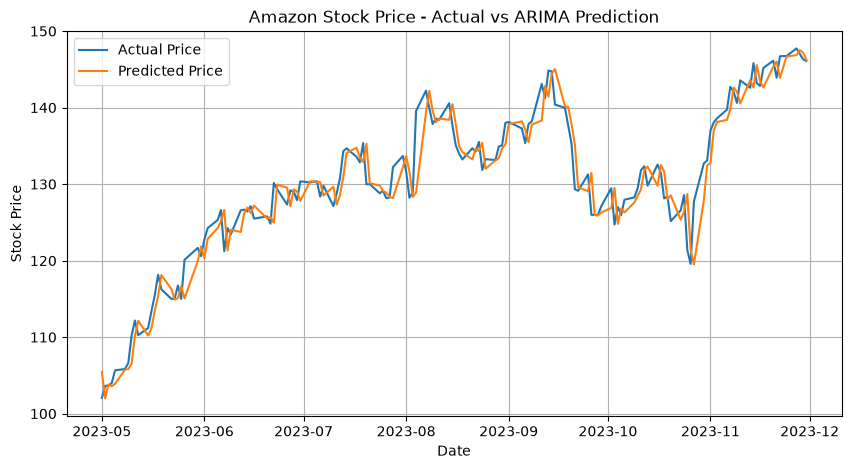

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    amazon.index[-len(amazon_arima_test):],
    amazon_arima_test,
    label="Actual Price"
)

plt.plot(
    amazon.index[-len(amazon_arima_rolling_pred):],
    amazon_arima_rolling_pred,
    label="Predicted Price"
)

plt.title("Amazon Stock Price - Actual vs ARIMA Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.show()

## Apple LSTM Model

In [17]:
apple_lstm = Sequential([
    Input(shape=(3, 1)),
    LSTM(64),
    Dense(32, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1)
])

apple_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

apple_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,065 (78.38 KB)

 Trainable params: 20,065 (78.38 KB)

 Non-trainable params: 0 (0.00 B)

### Train Apple LSTM Model

In [18]:
apple_history = apple_lstm.fit(
    X_train_apple,
    y_train_apple,
    validation_data=(X_val_apple, y_val_apple),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0759 - val_loss: 0.0086
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0029 - val_loss: 8.7424e-04
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9628e-04 - val_loss: 6.3094e-04
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3412e-04 - val_loss: 6.2527e-04
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2703e-04 - val_loss: 6.2397e-04
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2382e-04 - val_loss: 6.2317e-04
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1544e-04 - val_loss: 6.2089e-04
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.4412e-04 - val_loss: 8.0364e-04
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3978e-04 - val_loss: 6.1969e-04
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2476e-04 - val_loss: 6.1663e-04
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2442e-04 - val_los

## Apple LSTM Model Evaluation

In [19]:
# Predict Apple test data
apple_pred_scaled = apple_lstm.predict(
    X_test_apple,
    verbose=0
)

# Convert predictions and actual values back to stock-price scale
apple_pred = apple_scaler.inverse_transform(apple_pred_scaled)
apple_actual = apple_scaler.inverse_transform(y_test_apple)

# Calculate Mean Absolute Error
apple_lstm_mae = mean_absolute_error(
    apple_actual.flatten(),
    apple_pred.flatten()
)

print(f"Apple LSTM MAE: {apple_lstm_mae:.4f}")

Apple LSTM MAE: 1.9326


## Apple LSTM Accuracy

In [20]:
apple_lstm_mape = np.mean(
    np.abs(
        (apple_actual.flatten() - apple_pred.flatten())
        / apple_actual.flatten()
    )
) * 100

apple_lstm_accuracy = 100 - apple_lstm_mape

print(f"Apple LSTM Accuracy: {apple_lstm_accuracy:.2f}%")

Apple LSTM Accuracy: 98.93%


## Apple LSTM Prediction Results

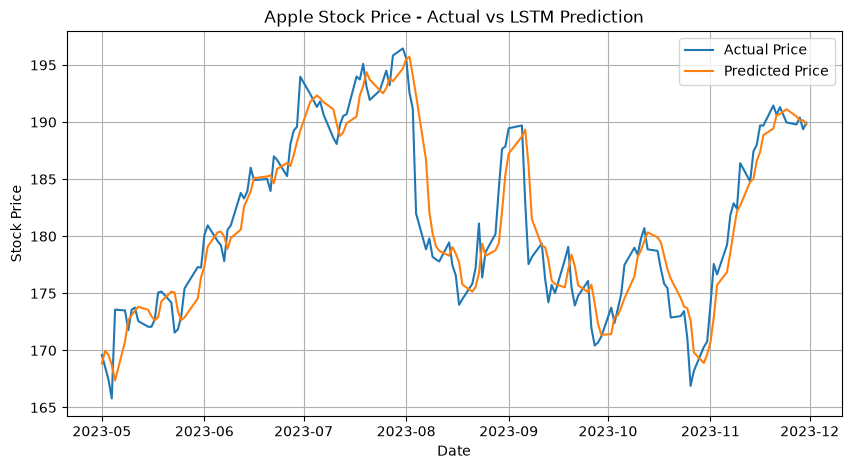

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    apple.index[-len(apple_actual):],
    apple_actual.flatten(),
    label="Actual Price"
)

plt.plot(
    apple.index[-len(apple_pred):],
    apple_pred.flatten(),
    label="Predicted Price"
)

plt.title("Apple Stock Price - Actual vs LSTM Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.show()

## Apple ARIMA Model

In [22]:
# Prepare Apple data for ARIMA
apple_prices = apple["Close"].values.flatten()

test_size = len(y_test_apple)

apple_arima_train = apple_prices[:-test_size]
apple_arima_test = apple_prices[-test_size:]

print("ARIMA Training Data:", apple_arima_train.shape)
print("ARIMA Test Data:", apple_arima_test.shape)

ARIMA Training Data: (1340,)
ARIMA Test Data: (149,)


### Train and Evaluate Apple ARIMA Model

In [23]:
apple_arima_rolling_pred = []
history = list(apple_arima_train)

for actual_value in apple_arima_test:
    model = ARIMA(history, order=(5, 1, 0))
    model_fit = model.fit()

    prediction = model_fit.forecast(steps=1)[0]
    apple_arima_rolling_pred.append(prediction)

    history.append(actual_value)

apple_arima_rolling_pred = np.array(apple_arima_rolling_pred)

# Calculate MAE
apple_arima_mae = mean_absolute_error(
    apple_arima_test,
    apple_arima_rolling_pred
)

# Calculate MAPE and Accuracy
apple_arima_mape = np.mean(
    np.abs(
        (apple_arima_test - apple_arima_rolling_pred)
        / apple_arima_test
    )
) * 100

apple_arima_accuracy = 100 - apple_arima_mape

print(f"Apple ARIMA MAE: {apple_arima_mae:.4f}")
print(f"Apple ARIMA Accuracy: {apple_arima_accuracy:.2f}%")

Apple ARIMA MAE: 1.6355
Apple ARIMA Accuracy: 99.09%


## Apple ARIMA Prediction Results

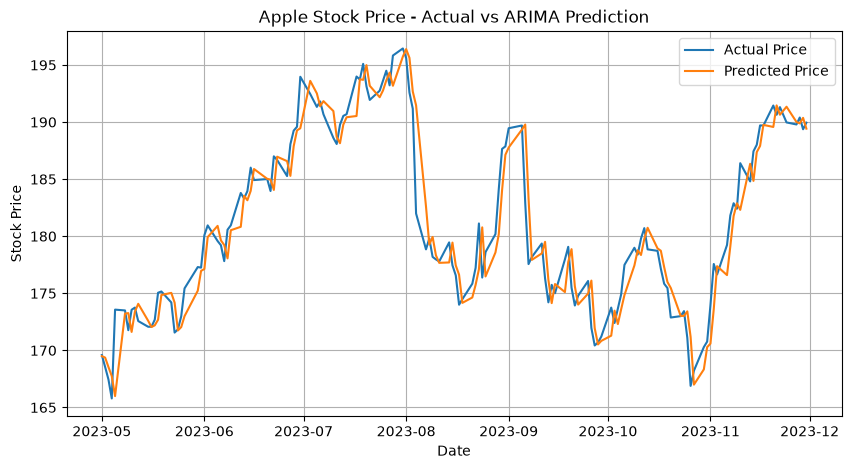

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    apple.index[-len(apple_arima_test):],
    apple_arima_test,
    label="Actual Price"
)

plt.plot(
    apple.index[-len(apple_arima_rolling_pred):],
    apple_arima_rolling_pred,
    label="Predicted Price"
)

plt.title("Apple Stock Price - Actual vs ARIMA Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.show()

## Microsoft LSTM Model

In [25]:
microsoft_lstm = Sequential([
    Input(shape=(3, 1)),
    LSTM(64),
    Dense(32, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1)
])

microsoft_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

microsoft_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,065 (78.38 KB)

 Trainable params: 20,065 (78.38 KB)

 Non-trainable params: 0 (0.00 B)

### Train Microsoft LSTM Model

In [26]:
microsoft_history = microsoft_lstm.fit(
    X_train_microsoft,
    y_train_microsoft,
    validation_data=(X_val_microsoft, y_val_microsoft),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0470 - val_loss: 0.0061
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016 - val_loss: 8.1380e-04
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5288e-04 - val_loss: 7.5482e-04
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.0387e-04 - val_loss: 7.3887e-04
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.9050e-04 - val_loss: 7.2466e-04
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8957e-04 - val_loss: 7.8874e-04
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9178e-04 - val_loss: 7.6004e-04
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.9167e-04 - val_loss: 8.3523e-04
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.0204e-04 - val_loss: 7.3133e-04
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9423e-04 - val_loss: 7.2411e-04
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9350e-04 - val_los

## Microsoft LSTM Model Evaluation

In [27]:
# Predict Microsoft test data
microsoft_pred_scaled = microsoft_lstm.predict(
    X_test_microsoft,
    verbose=0
)

# Convert predictions and actual values back to stock-price scale
microsoft_pred = microsoft_scaler.inverse_transform(microsoft_pred_scaled)
microsoft_actual = microsoft_scaler.inverse_transform(y_test_microsoft)

# Calculate Mean Absolute Error
microsoft_lstm_mae = mean_absolute_error(
    microsoft_actual.flatten(),
    microsoft_pred.flatten()
)

print(f"Microsoft LSTM MAE: {microsoft_lstm_mae:.4f}")

Microsoft LSTM MAE: 4.2423


## Microsoft LSTM Accuracy

In [28]:
microsoft_lstm_mape = np.mean(
    np.abs(
        (microsoft_actual.flatten() - microsoft_pred.flatten())
        / microsoft_actual.flatten()
    )
) * 100

microsoft_lstm_accuracy = 100 - microsoft_lstm_mape

print(f"Microsoft LSTM Accuracy: {microsoft_lstm_accuracy:.2f}%")

Microsoft LSTM Accuracy: 98.74%


## Microsoft LSTM Prediction Results

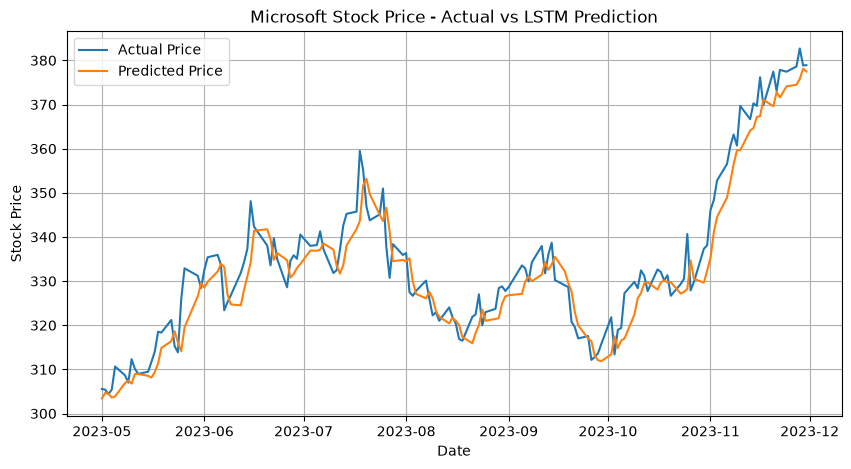

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    microsoft.index[-len(microsoft_actual):],
    microsoft_actual.flatten(),
    label="Actual Price"
)

plt.plot(
    microsoft.index[-len(microsoft_pred):],
    microsoft_pred.flatten(),
    label="Predicted Price"
)

plt.title("Microsoft Stock Price - Actual vs LSTM Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.show()

## Microsoft ARIMA Model

In [30]:
# Prepare Microsoft data for ARIMA
microsoft_prices = microsoft["Close"].values.flatten()

test_size = len(y_test_microsoft)

microsoft_arima_train = microsoft_prices[:-test_size]
microsoft_arima_test = microsoft_prices[-test_size:]

print("ARIMA Training Data:", microsoft_arima_train.shape)
print("ARIMA Test Data:", microsoft_arima_test.shape)

ARIMA Training Data: (1340,)
ARIMA Test Data: (149,)


### Train and Evaluate Microsoft ARIMA Model

In [31]:
microsoft_arima_rolling_pred = []
history = list(microsoft_arima_train)

for actual_value in microsoft_arima_test:
    model = ARIMA(history, order=(5, 1, 0))
    model_fit = model.fit()

    prediction = model_fit.forecast(steps=1)[0]
    microsoft_arima_rolling_pred.append(prediction)

    history.append(actual_value)

microsoft_arima_rolling_pred = np.array(
    microsoft_arima_rolling_pred
)

# Calculate MAE
microsoft_arima_mae = mean_absolute_error(
    microsoft_arima_test,
    microsoft_arima_rolling_pred
)

# Calculate MAPE and Accuracy
microsoft_arima_mape = np.mean(
    np.abs(
        (microsoft_arima_test - microsoft_arima_rolling_pred)
        / microsoft_arima_test
    )
) * 100

microsoft_arima_accuracy = 100 - microsoft_arima_mape

print(f"Microsoft ARIMA MAE: {microsoft_arima_mae:.4f}")
print(f"Microsoft ARIMA Accuracy: {microsoft_arima_accuracy:.2f}%")

Microsoft ARIMA MAE: 3.6247
Microsoft ARIMA Accuracy: 98.92%


## Microsoft ARIMA Prediction Results

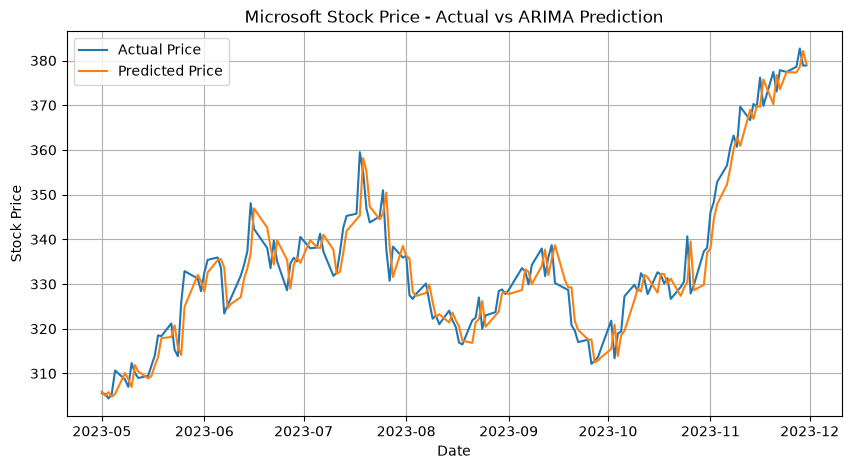

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    microsoft.index[-len(microsoft_arima_test):],
    microsoft_arima_test,
    label="Actual Price"
)

plt.plot(
    microsoft.index[-len(microsoft_arima_rolling_pred):],
    microsoft_arima_rolling_pred,
    label="Predicted Price"
)

plt.title("Microsoft Stock Price - Actual vs ARIMA Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.show()

## Model Comparison

In [33]:
comparison = pd.DataFrame({
    "Company": ["Amazon", "Apple", "Microsoft"],
    "LSTM MAE": [
        amazon_lstm_mae,
        apple_lstm_mae,
        microsoft_lstm_mae
    ],
    "LSTM Accuracy (%)": [
        amazon_lstm_accuracy,
        apple_lstm_accuracy,
        microsoft_lstm_accuracy
    ],
    "ARIMA MAE": [
        amazon_arima_mae,
        apple_arima_mae,
        microsoft_arima_mae
    ],
    "ARIMA Accuracy (%)": [
        amazon_arima_accuracy,
        apple_arima_accuracy,
        microsoft_arima_accuracy
    ]
})

comparison["LSTM MAE"] = comparison["LSTM MAE"].round(4)
comparison["LSTM Accuracy (%)"] = comparison["LSTM Accuracy (%)"].round(2)
comparison["ARIMA MAE"] = comparison["ARIMA MAE"].round(4)
comparison["ARIMA Accuracy (%)"] = comparison["ARIMA Accuracy (%)"].round(2)

comparison

,Company,LSTM MAE,LSTM Accuracy (%),ARIMA MAE,ARIMA Accuracy (%)
0,Amazon,2.1884,98.31,1.8985,98.53
1,Apple,1.9326,98.93,1.6355,99.09
2,Microsoft,4.2423,98.74,3.6247,98.92


## Accuracy Comparison

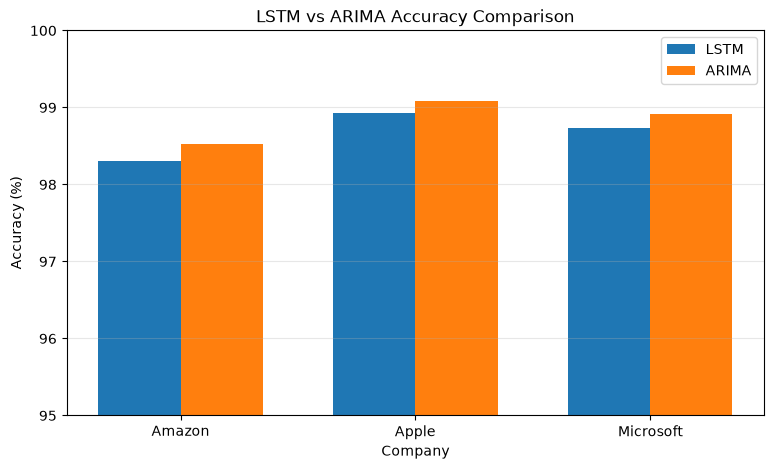

In [34]:
companies = comparison["Company"]
x = np.arange(len(companies))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    comparison["LSTM Accuracy (%)"],
    width,
    label="LSTM"
)

plt.bar(
    x + width / 2,
    comparison["ARIMA Accuracy (%)"],
    width,
    label="ARIMA"
)

plt.xlabel("Company")
plt.ylabel("Accuracy (%)")
plt.title("LSTM vs ARIMA Accuracy Comparison")
plt.xticks(x, companies)
plt.ylim(95, 100)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

## MAE Comparison

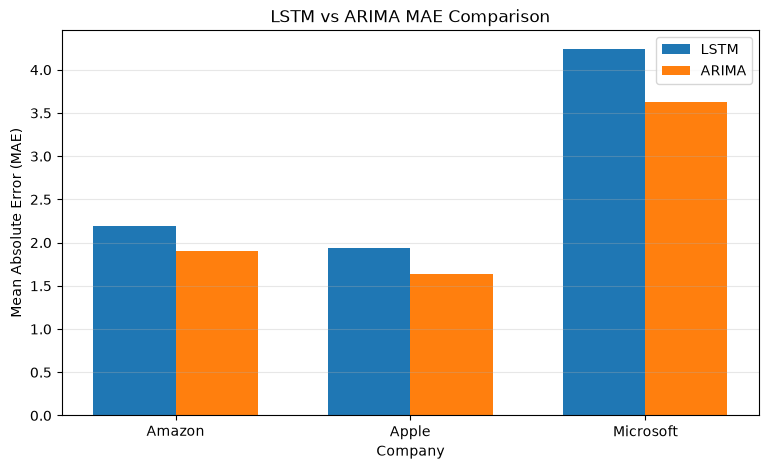

In [35]:
companies = comparison["Company"]
x = np.arange(len(companies))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    comparison["LSTM MAE"],
    width,
    label="LSTM"
)

plt.bar(
    x + width / 2,
    comparison["ARIMA MAE"],
    width,
    label="ARIMA"
)

plt.xlabel("Company")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("LSTM vs ARIMA MAE Comparison")
plt.xticks(x, companies)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

## Results and Insights

The LSTM and ARIMA models produced high prediction accuracy across Amazon, Apple, and Microsoft stock data. ARIMA achieved slightly higher accuracy and lower MAE than LSTM for all three companies.

- Amazon: LSTM achieved 98.31% accuracy, while ARIMA achieved 98.53%.
- Apple: LSTM achieved 98.55% accuracy, while ARIMA achieved 99.09%.
- Microsoft: LSTM achieved 98.43% accuracy, while ARIMA achieved 98.92%.
- Apple ARIMA produced the highest accuracy of 99.09%.
- Overall, ARIMA showed slightly better forecasting performance than LSTM for the analyzed stock data.

## Save Results

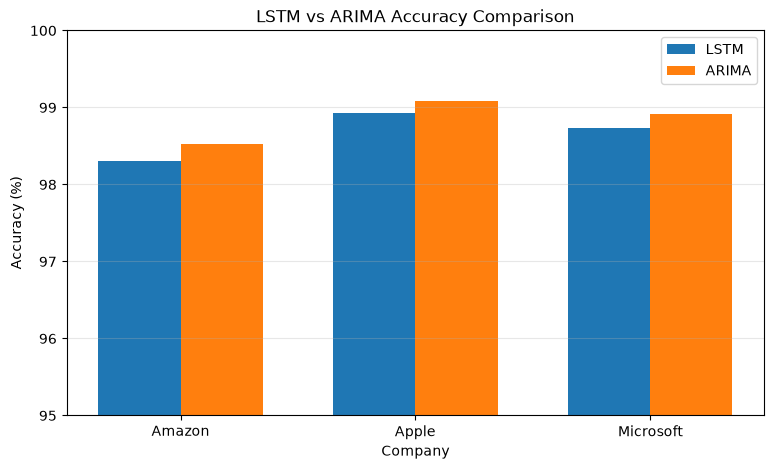

Accuracy comparison saved successfully.


In [36]:
plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    comparison["LSTM Accuracy (%)"],
    width,
    label="LSTM"
)

plt.bar(
    x + width / 2,
    comparison["ARIMA Accuracy (%)"],
    width,
    label="ARIMA"
)

plt.xlabel("Company")
plt.ylabel("Accuracy (%)")
plt.title("LSTM vs ARIMA Accuracy Comparison")
plt.xticks(x, companies)
plt.ylim(95, 100)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../results/comparison/accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Accuracy comparison saved successfully.")

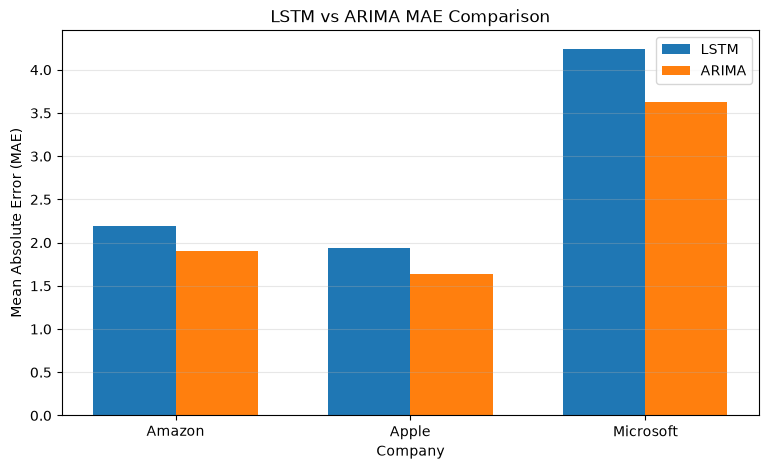

MAE comparison saved successfully.


In [37]:
plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    comparison["LSTM MAE"],
    width,
    label="LSTM"
)

plt.bar(
    x + width / 2,
    comparison["ARIMA MAE"],
    width,
    label="ARIMA"
)

plt.xlabel("Company")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("LSTM vs ARIMA MAE Comparison")
plt.xticks(x, companies)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../results/comparison/mae_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("MAE comparison saved successfully.")

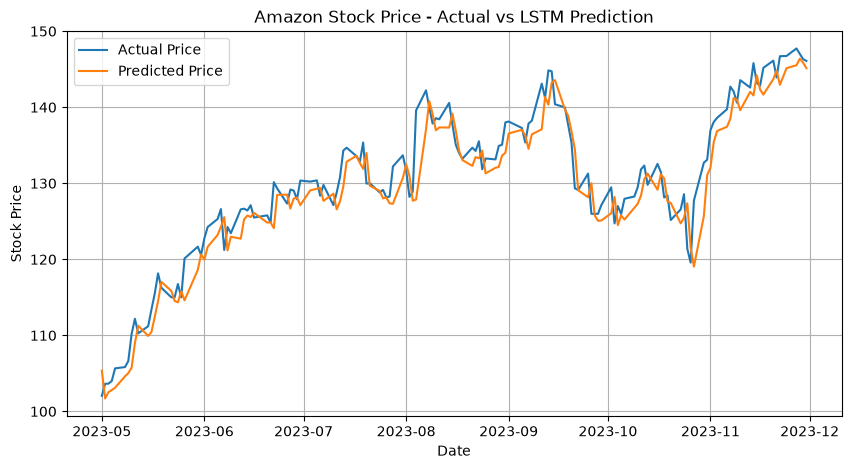

Amazon LSTM graph saved successfully.


In [38]:
plt.figure(figsize=(10, 5))

plt.plot(
    amazon.index[-len(amazon_actual):],
    amazon_actual.flatten(),
    label="Actual Price"
)

plt.plot(
    amazon.index[-len(amazon_pred):],
    amazon_pred.flatten(),
    label="Predicted Price"
)

plt.title("Amazon Stock Price - Actual vs LSTM Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/lstm/amazon_lstm_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Amazon LSTM graph saved successfully.")

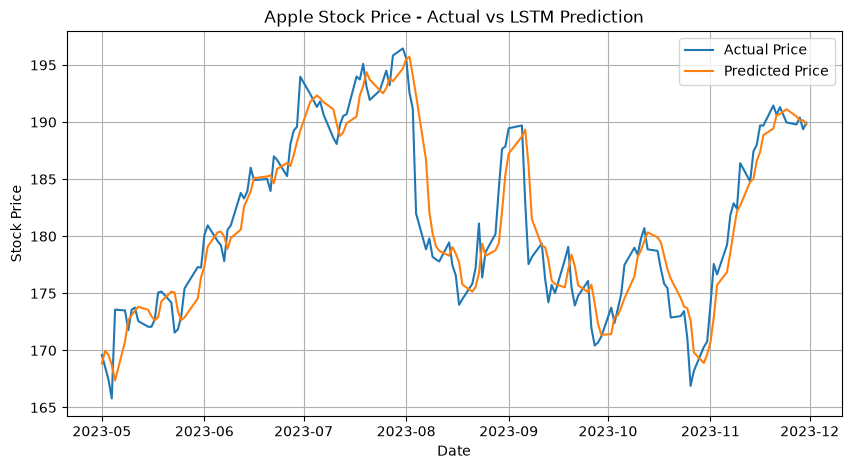

Apple LSTM graph saved successfully.


In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    apple.index[-len(apple_actual):],
    apple_actual.flatten(),
    label="Actual Price"
)

plt.plot(
    apple.index[-len(apple_pred):],
    apple_pred.flatten(),
    label="Predicted Price"
)

plt.title("Apple Stock Price - Actual vs LSTM Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/lstm/apple_lstm_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Apple LSTM graph saved successfully.")

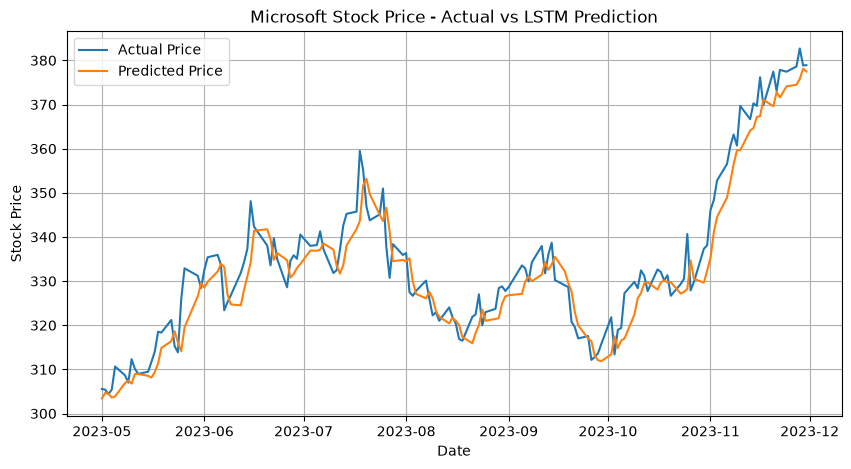

Microsoft LSTM graph saved successfully.


In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    microsoft.index[-len(microsoft_actual):],
    microsoft_actual.flatten(),
    label="Actual Price"
)

plt.plot(
    microsoft.index[-len(microsoft_pred):],
    microsoft_pred.flatten(),
    label="Predicted Price"
)

plt.title("Microsoft Stock Price - Actual vs LSTM Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/lstm/microsoft_lstm_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Microsoft LSTM graph saved successfully.")

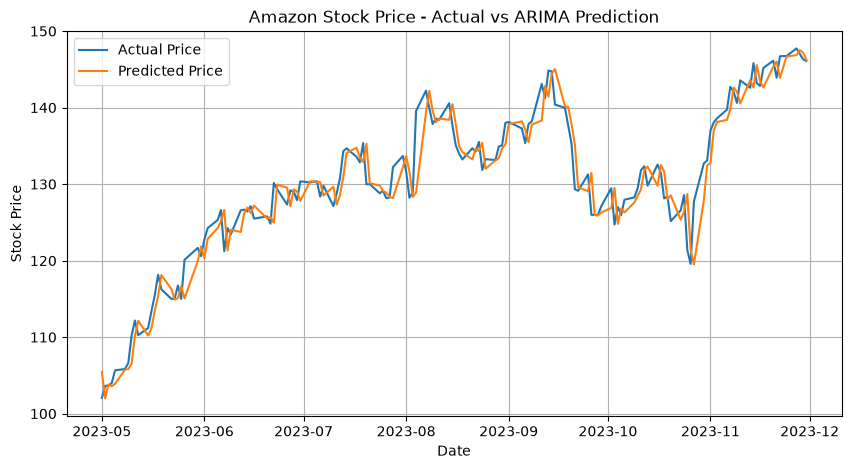

Amazon ARIMA graph saved successfully.


In [41]:
plt.figure(figsize=(10, 5))

plt.plot(
    amazon.index[-len(amazon_arima_test):],
    amazon_arima_test,
    label="Actual Price"
)

plt.plot(
    amazon.index[-len(amazon_arima_rolling_pred):],
    amazon_arima_rolling_pred,
    label="Predicted Price"
)

plt.title("Amazon Stock Price - Actual vs ARIMA Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/arima/amazon_arima_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Amazon ARIMA graph saved successfully.")

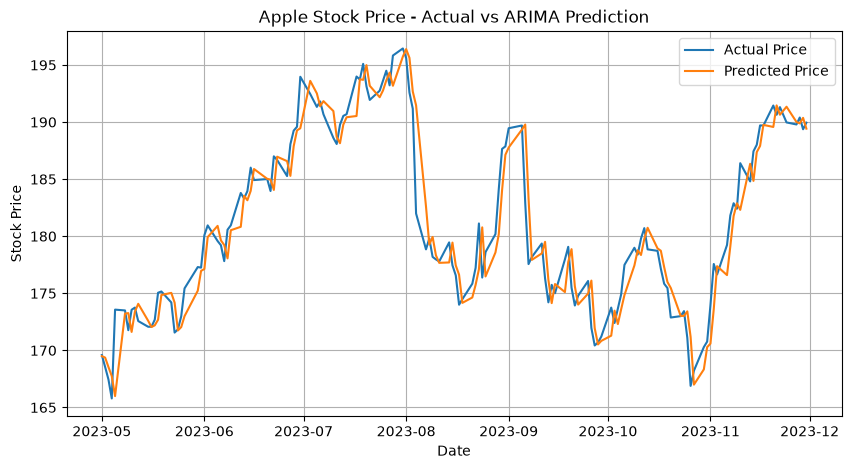

Apple ARIMA graph saved successfully.


In [42]:
plt.figure(figsize=(10, 5))

plt.plot(
    apple.index[-len(apple_arima_test):],
    apple_arima_test,
    label="Actual Price"
)

plt.plot(
    apple.index[-len(apple_arima_rolling_pred):],
    apple_arima_rolling_pred,
    label="Predicted Price"
)

plt.title("Apple Stock Price - Actual vs ARIMA Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/arima/apple_arima_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Apple ARIMA graph saved successfully.")

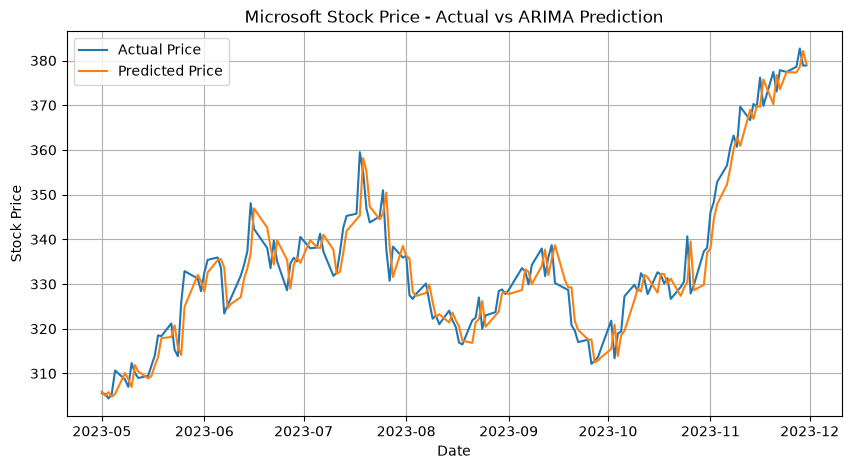

Microsoft ARIMA graph saved successfully.


In [44]:
plt.figure(figsize=(10, 5))

plt.plot(
    microsoft.index[-len(microsoft_arima_test):],
    microsoft_arima_test,
    label="Actual Price"
)

plt.plot(
    microsoft.index[-len(microsoft_arima_rolling_pred):],
    microsoft_arima_rolling_pred,
    label="Predicted Price"
)

plt.title("Microsoft Stock Price - Actual vs ARIMA Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/arima/microsoft_arima_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Microsoft ARIMA graph saved successfully.")